In [1]:
import jax
import jax.numpy as jnp

global_list = []

def log2(x):
    global_list.append(x)
    ln_x = jnp.log(x)
    ln_2 = jnp.log(2.0)
    return ln_x / ln_2

print(jax.make_jaxpr(log2)(3.0))

{ lambda ; a:f32[]. let
    b:f32[] = log a
    c:f32[] = log 2.0:f32[]
    d:f32[] = div b c
  in (d,) }


In [2]:
def log2_with_print(x):
    print("printed x:", x)
    ln_x = jnp.log(x)
    ln_2 = jnp.log(2.0)
    return ln_x / ln_x

print(jax.make_jaxpr(log2_with_print)(3.))

printed x: JitTracer(~float32[])
{ lambda ; a:f32[]. let
    b:f32[] = log a
    _:f32[] = log 2.0:f32[]
    c:f32[] = div b b
  in (c,) }


In [3]:
def log2_if_rank_2(x):
    if x.ndim == 2:
        ln_x = jnp.log(x)
        ln_2 = jnp.log(2.0)
        return ln_x / ln_2
    else:
        return x

print(jax.make_jaxpr(log2_if_rank_2)(jnp.array([1, 2, 3])))

{ lambda ; a:i32[3]. let  in (a,) }


In [4]:
def selu(x, alpha=1.67, lambda_=1.05):
    return lambda_ * jnp.where(x > 0, x, alpha * jnp.exp(x) - alpha)

x = jnp.arange(1_000_000)
%timeit selu(x).block_until_ready()

124 μs ± 2.91 μs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


In [5]:
selu_jit = jax.jit(selu)

selu_jit(x).block_until_ready()

Array([0.0000000e+00, 1.0500000e+00, 2.0999999e+00, ..., 1.0499968e+06,
       1.0499979e+06, 1.0499989e+06], dtype=float32)

In [6]:
%timeit selu_jit(x).block_until_ready()

36.6 μs ± 1.43 μs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


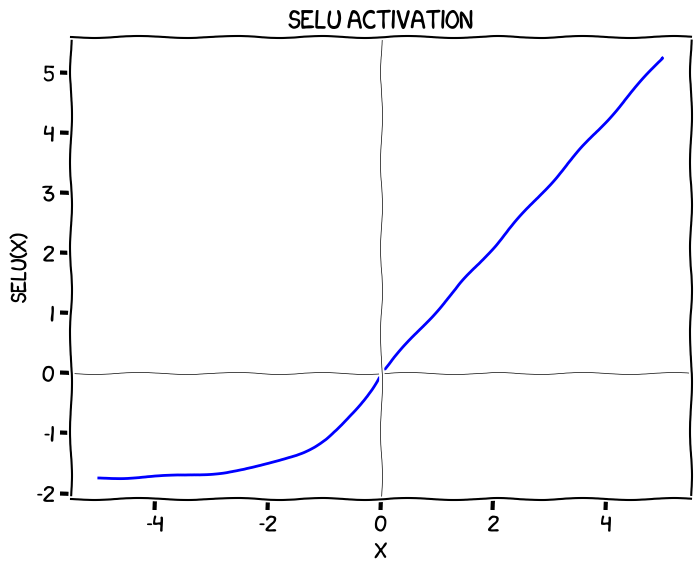

In [7]:
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import font_manager

plt.xkcd()
font_family = None
for f in font_manager.fontManager.ttflist:
    if "xkcd" in f.name.lower():
        font_family = f.name
        break
if font_family is not None:
    plt.rcParams['font.family'] = font_family

def selu(x, alpha=1.67, lambda_=1.05):
    return lambda_ * jnp.where(x > 0, x, alpha * jnp.exp(x) - alpha)

x = jnp.linspace(-5, 5, 200)
y = selu(x)

fig, ax = plt.subplots(figsize=(8, 6), dpi=100)
ax.plot(np.asarray(x), np.asarray(y), 'b-', linewidth=2)
ax.axhline(0, color='k', linewidth=0.5)
ax.axvline(0, color='k', linewidth=0.5)
ax.set_xlabel('X')
ax.set_ylabel('SELU(X)')
ax.set_title('SELU ACTIVATION')
plt.show()


In [8]:
def f(x):
    if x > 0:
        return x
    else:
        return 2 * x

try:
    jax.jit(f)(10)
except Exception as ex:
    print(ex)

Attempted boolean conversion of traced array with shape bool[].
The error occurred while tracing the function f at /tmp/ipykernel_2279848/711600190.py:1 for jit. This concrete value was not available in Python because it depends on the value of the argument x.
See https://docs.jax.dev/en/latest/errors.html#jax.errors.TracerBoolConversionError


In [9]:
try:
    print(jax.make_jaxpr(f)(10))
except Exception as ex:
    print(ex)

Attempted boolean conversion of traced array with shape bool[].
The error occurred while tracing the function f at /tmp/ipykernel_2279848/711600190.py:1 for jit. This concrete value was not available in Python because it depends on the value of the argument x.
See https://docs.jax.dev/en/latest/errors.html#jax.errors.TracerBoolConversionError


In [10]:
def g(x, n):
    i = 0
    while i < n:
        i += 1
    return x + i

try:
    jax.jit(g)(10, 20)
except Exception as ex:
    print(ex)

Attempted boolean conversion of traced array with shape bool[].
The error occurred while tracing the function g at /tmp/ipykernel_2279848/3234304838.py:1 for jit. This concrete value was not available in Python because it depends on the value of the argument n.
See https://docs.jax.dev/en/latest/errors.html#jax.errors.TracerBoolConversionError


In [11]:
@jax.jit
def loop_body(prev_i):
    return prev_i + 1

def g_inner_jitted(x, n):
    i = 0
    while i < n:
        i = loop_body(i)
    return x + i

g_inner_jitted(10, 20)

Array(30, dtype=int32, weak_type=True)

In [12]:
f_jit_correct = jax.jit(f, static_argnums=0)

print(f_jit_correct(10))

10


In [13]:
g_jit_correct = jax.jit(g, static_argnames="n")

In [14]:
print(g_jit_correct(10, 20))

30


In [15]:
from functools import partial

@partial(jax.jit, static_argnames=["n"])
def g_jit_decorated(x, n):
    i = 0
    while i < n:
        i += 1
    return x + i

print(g_jit_decorated(10, 20))

30
